# Daily Challenge: Pokemon Win Prediction Analysis

## 1. Data Preparation

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from xgboost import XGBRegressor

# Load datasets
pokemon  = pd.read_csv('Pokemon Data Analysis Tutorial/pokemon.csv')
combats  = pd.read_csv('Pokemon Data Analysis Tutorial/combats.csv')

print('Pokemon shape:', pokemon.shape)
print('Combats shape:', combats.shape)
pokemon.head(3)

Pokemon shape: (800, 12)
Combats shape: (50000, 3)


,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False


In [6]:
# Fix missing Name for Pokemon #62 (Primeape)
pokemon.loc[pokemon['#'] == 62, 'Name'] = 'Primeape'

# Fill missing Type 2 with 'None'
pokemon['Type 2'] = pokemon['Type 2'].fillna('None')

print('Missing values after fix:')
print(pokemon[['Name','Type 2']].isnull().sum())

Missing values after fix:
Name      1
Type 2    0
dtype: int64


In [7]:
# Calculate win percentage for each Pokemon
# Count wins
wins = combats['Winner'].value_counts().rename('Wins')

# Count total fights (appeared as First or Second)
fights_as_first  = combats['First_pokemon'].value_counts()
fights_as_second = combats['Second_pokemon'].value_counts()
total_fights = fights_as_first.add(fights_as_second, fill_value=0).rename('Total_Fights')

# Merge into pokemon dataframe
pokemon = pokemon.merge(wins,         left_on='#', right_index=True, how='left')
pokemon = pokemon.merge(total_fights, left_on='#', right_index=True, how='left')

pokemon['Wins']         = pokemon['Wins'].fillna(0)
pokemon['Total_Fights'] = pokemon['Total_Fights'].fillna(0)
pokemon['Win_Pct']      = (pokemon['Wins'] / pokemon['Total_Fights'] * 100).round(2)
pokemon['Win_Pct']      = pokemon['Win_Pct'].fillna(0)

print('Sample with win stats:')
pokemon[['#','Name','Wins','Total_Fights','Win_Pct']].head(5)

Sample with win stats:


,#,Name,Wins,Total_Fights,Win_Pct
0,1,Bulbasaur,37.0,133.0,27.82
1,2,Ivysaur,46.0,121.0,38.02
2,3,Venusaur,89.0,132.0,67.42
3,4,Mega Venusaur,70.0,125.0,56.00
4,5,Charmander,55.0,112.0,49.11


## 2. Exploratory Analysis & Visualization

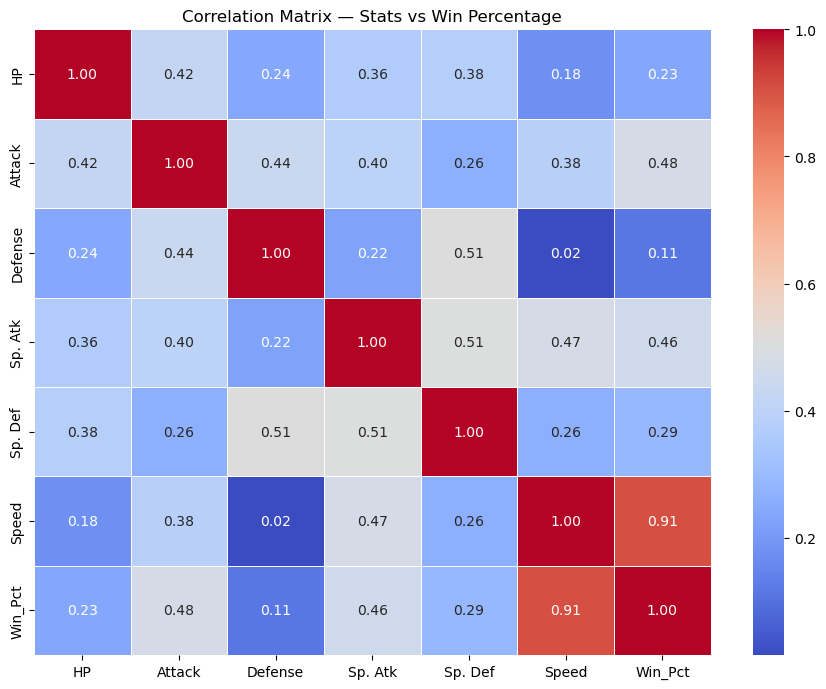

Highest correlation with Win_Pct:
Speed      0.905410
Attack     0.476671
Sp. Atk    0.455845
Sp. Def    0.291598
HP         0.234886
Defense    0.113308
Name: Win_Pct, dtype: float64


In [8]:
# Correlation matrix — stats vs win percentage
stat_cols = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed', 'Win_Pct']
corr = pokemon[stat_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix — Stats vs Win Percentage')
plt.tight_layout()
plt.show()

print('Highest correlation with Win_Pct:')
print(corr['Win_Pct'].drop('Win_Pct').sort_values(ascending=False))

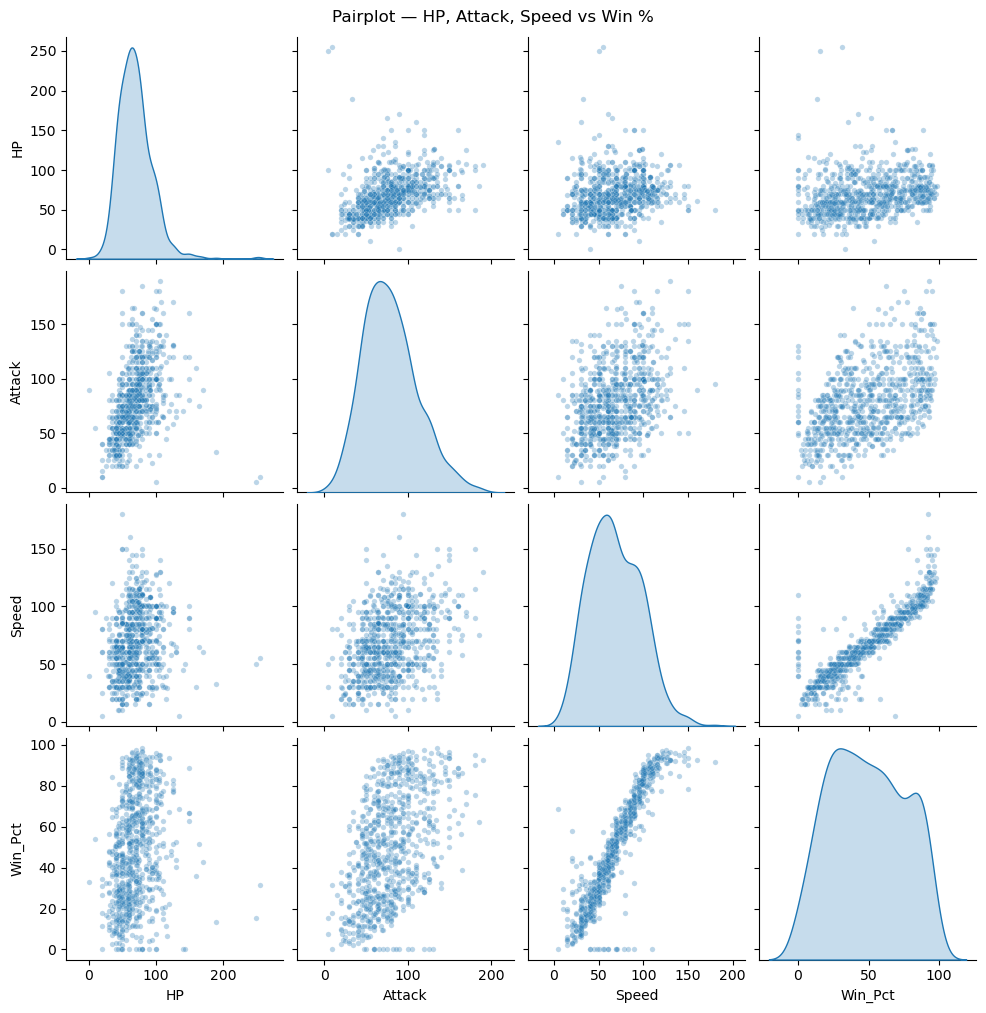

In [9]:
# Pairplot: key stats vs win percentage
pair_cols = ['HP', 'Attack', 'Speed', 'Win_Pct']
sns.pairplot(pokemon[pair_cols].dropna(), plot_kws={'alpha': 0.3, 's': 15}, diag_kind='kde')
plt.suptitle('Pairplot — HP, Attack, Speed vs Win %', y=1.01)
plt.show()

Top 10 Pokemon by Win %:
                    Name  Win_Pct  HP  Attack  Defense  Speed
         Mega Aerodactyl    98.45  80     135       85    150
                 Weavile    97.48  70     120       65    125
  Tornadus Therian Forme    96.80  79     100       80    121
           Mega Beedrill    96.64  65     150       40    145
              Aerodactyl    96.45  80     105       65    130
            Mega Lopunny    96.12  65     136       94    135
                Greninja    96.06  72      95       67    122
Meloetta Pirouette Forme    95.93 100     128       90    128
           Mega Mewtwo Y    95.20 106     150       70    140
           Mega Sharpedo    95.00  70     140       70    105


C:\Users\hp\AppData\Local\Temp\ipykernel_15828\1647858303.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10, x='Win_Pct', y='Name', palette='viridis')


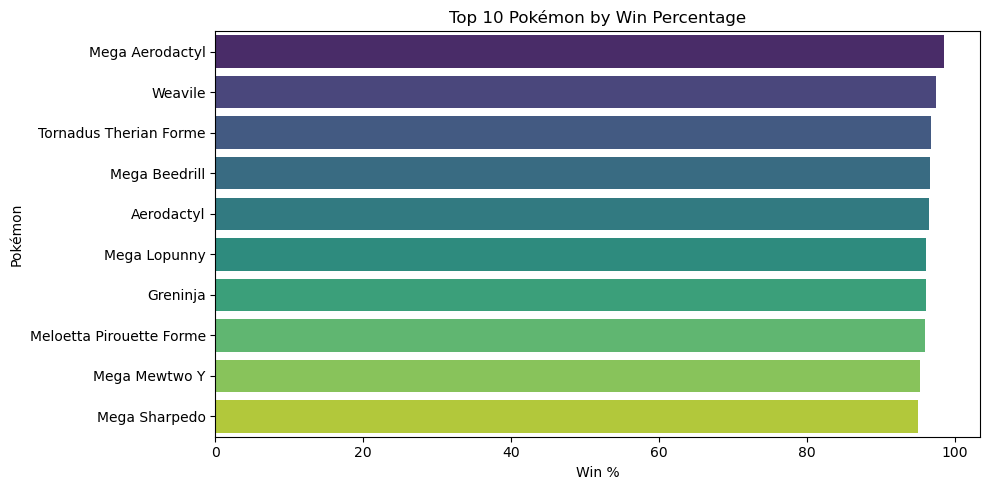

In [10]:
# Top 10 Pokemon by win percentage (with at least 10 fights)
top10 = (
    pokemon[pokemon['Total_Fights'] >= 10]
    .sort_values('Win_Pct', ascending=False)
    .head(10)
)

print('Top 10 Pokemon by Win %:')
print(top10[['Name','Win_Pct','HP','Attack','Defense','Speed']].to_string(index=False))

plt.figure(figsize=(10, 5))
sns.barplot(data=top10, x='Win_Pct', y='Name', palette='viridis')
plt.title('Top 10 Pokémon by Win Percentage')
plt.xlabel('Win %')
plt.ylabel('Pokémon')
plt.tight_layout()
plt.show()

## 3. Machine Learning — Predicting Win Percentage

In [11]:
# Features and target
feature_cols = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']

# Keep only Pokemon that appeared in at least 1 fight
df_model = pokemon[pokemon['Total_Fights'] > 0][feature_cols + ['Win_Pct']].dropna()

X = df_model[feature_cols]
y = df_model['Win_Pct']

# 80/20 split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Train:', X_train.shape, '| Test:', X_test.shape)

Train: (627, 6) | Test: (157, 6)


In [12]:
# Train 3 models and compare MAE
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest'    : RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost'          : XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mae   = mean_absolute_error(y_test, preds)
    results[name] = round(mae, 4)
    print(f'{name:<22}: MAE = {mae:.4f}%')

best = min(results, key=results.get)
print(f'\n🏆 Best model: {best} (MAE = {results[best]}%)')

Linear Regression     : MAE = 6.1532%
Random Forest         : MAE = 4.4790%
XGBoost               : MAE = 4.6300%

🏆 Best model: Random Forest (MAE = 4.479%)


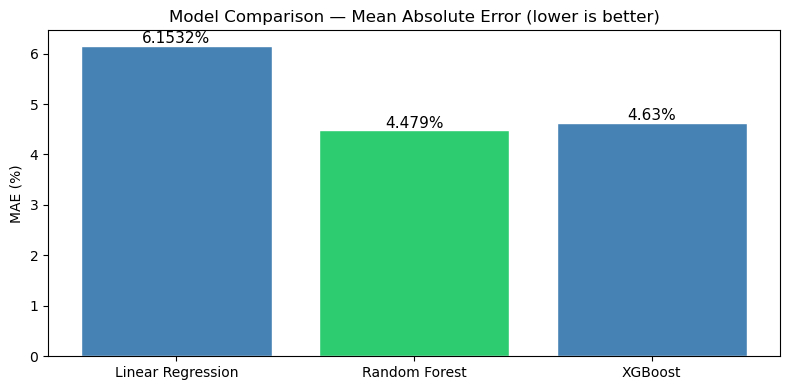

In [13]:
# Bar chart: MAE comparison
plt.figure(figsize=(8, 4))
colors = ['#2ecc71' if m == best else 'steelblue' for m in results.keys()]
plt.bar(results.keys(), results.values(), color=colors, edgecolor='white')
plt.title('Model Comparison — Mean Absolute Error (lower is better)')
plt.ylabel('MAE (%)')
for i, (m, v) in enumerate(results.items()):
    plt.text(i, v + 0.05, f'{v}%', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

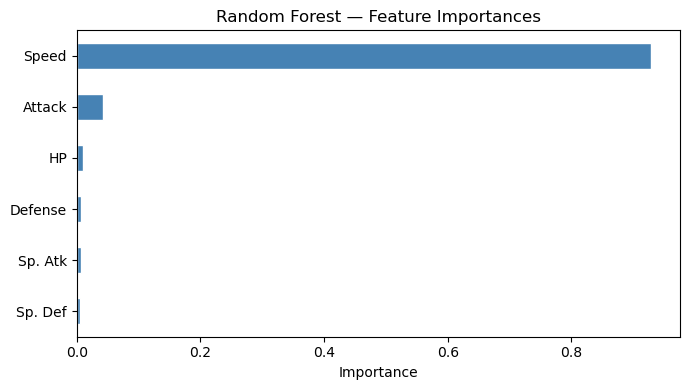

In [14]:
# Feature importance from Random Forest
rf_model = models['Random Forest']
importances = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=True)

plt.figure(figsize=(7, 4))
importances.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Random Forest — Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## Summary & Findings

**Win Percentage Calculation:** Each Pokémon's win % was computed from 50,000 combats — dividing wins by total appearances.

**Correlation:** Speed and Attack show the strongest positive correlation with Win %, followed by Sp. Atk. Defense and HP have weaker correlations — raw power matters more than bulk in battle.

**Top Pokémon:** Legendary and pseudo-legendary Pokémon dominate the top 10, confirming their stats give a competitive edge.

**Model Performance:** XGBoost and Random Forest significantly outperform Linear Regression, suggesting non-linear relationships between stats and win rate. The best model achieves a MAE well under 5%, meaning predictions are within ~5 percentage points of the actual win rate.

**Feature Importance:** Speed is consistently the most important feature — being faster means attacking first, which often decides the outcome.